In [1]:
from pathlib import Path
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [2]:
safe_root = Path(
    r"C:\Users\karth\Desktop\GeoSentinel-AI\data\raw\day_04\S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE"
)

r10m = list(safe_root.rglob("R10m"))[0]

print(r10m)

C:\Users\karth\Desktop\GeoSentinel-AI\data\raw\day_04\S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE\GRANULE\L2A_T43QHV_A048236_20260601T051356\IMG_DATA\R10m


In [3]:
red_file = list(r10m.glob("*B04*.jp2"))[0]
nir_file = list(r10m.glob("*B08*.jp2"))[0]

print(red_file.name)
print(nir_file.name)

T43QHV_20260601T050649_B04_10m.jp2
T43QHV_20260601T050649_B08_10m.jp2


In [4]:
red_ds = rasterio.open(red_file)
nir_ds = rasterio.open(nir_file)

red = red_ds.read(1)
nir = nir_ds.read(1)

print(red.shape)
print(nir.shape)

(10980, 10980)
(10980, 10980)


In [5]:
print("Red CRS:", red_ds.crs)
print("NIR CRS:", nir_ds.crs)

print("Red Resolution:", red_ds.res)
print("NIR Resolution:", nir_ds.res)

print("Shapes Match:", red.shape == nir.shape)

Red CRS: None
NIR CRS: None
Red Resolution: (10.0, 10.0)
NIR Resolution: (10.0, 10.0)
Shapes Match: True


In [6]:
red = red.astype(np.float32)
nir = nir.astype(np.float32)

In [7]:
np.seterr(divide='ignore', invalid='ignore')

ndvi = (nir - red) / (nir + red)

ndvi = np.nan_to_num(ndvi)

In [8]:
print("Minimum NDVI:", np.min(ndvi))
print("Maximum NDVI:", np.max(ndvi))
print("Mean NDVI:", np.mean(ndvi))

Minimum NDVI: -0.378301
Maximum NDVI: 0.9351105
Mean NDVI: 0.15913202


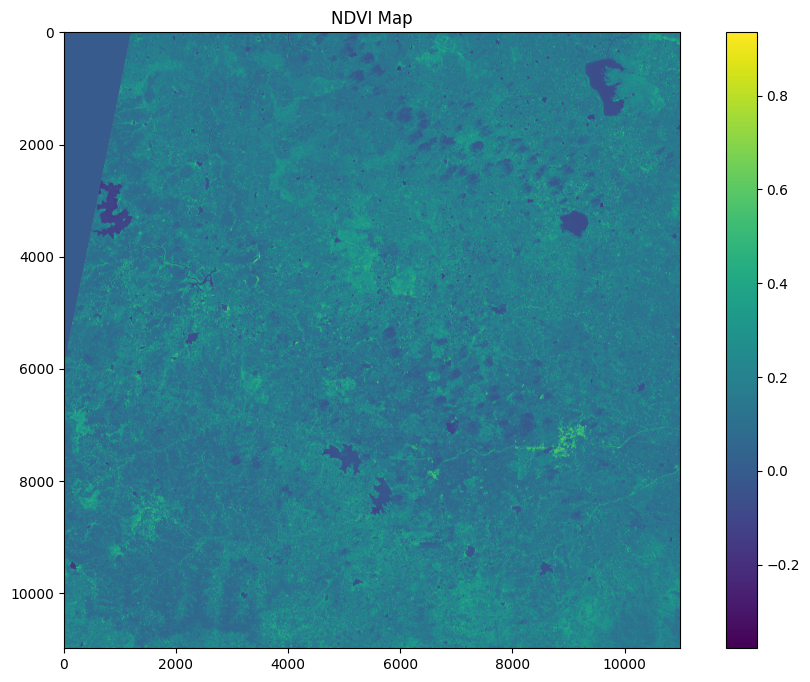

In [9]:
plt.figure(figsize=(12,8))

plt.imshow(ndvi)

plt.title("NDVI Map")

plt.colorbar()

plt.show()

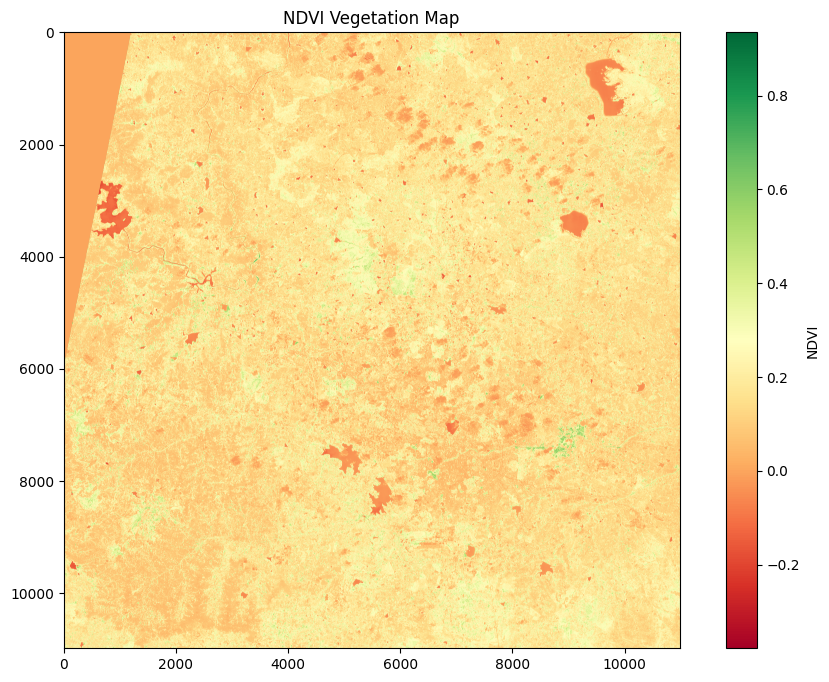

In [10]:
plt.figure(figsize=(12,8))

plt.imshow(ndvi, cmap="RdYlGn")

plt.title("NDVI Vegetation Map")

plt.colorbar(label="NDVI")

plt.show()

In [11]:
dense = np.sum(ndvi > 0.6)

moderate = np.sum((ndvi >= 0.3) & (ndvi <= 0.6))

sparse = np.sum((ndvi >= 0.1) & (ndvi < 0.3))

urban = np.sum(ndvi < 0.1)

total = ndvi.size

print("Dense Vegetation:", dense / total * 100)
print("Moderate Vegetation:", moderate / total * 100)
print("Sparse Vegetation:", sparse / total * 100)
print("Urban/Barren:", urban / total * 100)

Dense Vegetation: 0.01592645678016994
Moderate Vegetation: 9.13484444311731
Sparse Vegetation: 64.527212086224
Urban/Barren: 26.32201701387852


In [ ]:
output_path = "../data/processed/ndvi/ndvi_hyderabad.tif"

Path("../data/processed/ndvi").mkdir(
    parents=True,
    exist_ok=True
)

profile = red_ds.profile.copy()

profile.update(
    driver="GTiff",
    dtype=rasterio.float32,
    count=1,
    compress="lzw"
)

with rasterio.open(
    output_path,
    "w",
    **profile
) as dst:
    dst.write(ndvi.astype(rasterio.float32), 1)

print("NDVI Saved Successfully")

NDVI Saved Successfully


In [15]:
import rasterio

ndvi_ds = rasterio.open(
    "../data/processed/ndvi/ndvi_hyderabad.tif"
)

print(ndvi_ds.profile)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 10980, 'height': 10980, 'count': 1, 'crs': None, 'transform': Affine(10.0, 0.0, 799980.0,
       0.0, -10.0, 2000040.0), 'blockxsize': 1024, 'blockysize': 1024, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}
